# Notebook 11: Data Center Signature — Stage B prototype

**One Sensor, One Year — Edition 2: US Grid**

Ed1's anchor was seasonal (monsoon → CO₂ intensity). The proposed Ed2 anchor is diurnal and regional: **AI-driven data center load is flattening America's overnight trough, and the flattening is regionally uneven.**

This notebook is the **Stage B prototype** — a 2025-only cross-sectional test before committing to the 2019–2024 per-BA historical backfill. If the 2025 snapshot already shows hyperscaler-heavy BAs (PJM, ERCO, MISO) with meaningfully different load shapes than periphery BAs (BPAT, CISO, ISNE), the full trend story is very likely real and worth pulling. If not, we pivot.

**The three signatures (cross-sectional, 2025):**
1. **Overnight share** = mean(demand 2am–5am) / daily peak. Data-center-heavy grids should be higher.
2. **Weekend ratio** = mean(weekend demand) / mean(weekday demand). 24/7 server load shrinks the traditional ~5% weekend dip.
3. **Load duration curve** = sorted-descending hourly generation, normalized to peak. Data-center-heavy grids should have a fatter bottom.

**Input:** `../data/processed/ba_2025_hourly.parquet` (10 BAs × hourly × fuel type)

**Caveat:** the parquet contains per-fuel generation, not a direct demand series. We sum all fuels (including battery BAT) as a demand proxy. Per-BA trade imbalances are small relative to demand shape and don't flip the overnight pattern.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
raw = pd.read_parquet(PROCESSED / 'ba_2025_hourly.parquet')

# Sum across fuels to get a total-generation proxy for demand per (BA, hour).
gen = (raw.groupby(['respondent', 'period'])['value_mwh']
          .sum()
          .unstack('respondent')
          .sort_index())

gen.index = pd.to_datetime(gen.index)
print(f'Shape: {gen.shape}  (hours × BAs)')
print(f'Time range: {gen.index.min()} → {gen.index.max()}')
print(f'BAs: {list(gen.columns)}')
gen.describe().round(0).loc[['mean', 'min', 'max']]

Shape: (8760, 10)  (hours × BAs)
Time range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
BAs: ['BPAT', 'CISO', 'ERCO', 'ISNE', 'MISO', 'NYIS', 'PJM', 'SOCO', 'SWPP', 'TVA']


respondent,BPAT,CISO,ERCO,ISNE,MISO,NYIS,PJM,SOCO,SWPP,TVA
mean,9394.0,21271.0,55722.0,12228.0,75240.0,15119.0,99722.0,28748.0,34536.0,18520.0
min,4376.0,8519.0,38320.0,0.0,48498.0,8891.0,68553.0,17828.0,24265.0,11287.0
max,16318.0,43952.0,83571.0,22928.0,115692.0,29342.0,162721.0,86525.0,57228.0,29322.0


## BA grouping

**Hyperscaler-heavy BAs** (where AI/cloud capex concentrates):
- **PJM** — covers Virginia's "data center alley" (Dominion), Ohio, northeast corridor. No sub-BA split in EIA-930 so the signal is diluted by the whole PJM footprint.
- **ERCO** — Texas. Dallas + San Antonio hyperscaler growth. Cleanest signature because ERCOT is geographically focused.
- **MISO** — Ohio/Indiana data center corridor, plus Iowa clusters.

**Control BAs** (hyperscaler presence is minimal or load shape dominated by other factors):
- **BPAT** — Pacific Northwest, hydro-heavy, residential+industrial mix.
- **CISO** — California. Heavy solar penetration reshapes load already for non-data-center reasons.
- **ISNE**, **NYIS**, **SOCO**, **SWPP**, **TVA** — other regions for context.

If the data-center hypothesis holds, the three hyperscaler BAs should visibly cluster on all three signature metrics.

In [2]:
HYPERSCALER = ['PJM', 'ERCO', 'MISO']
CONTROL     = ['BPAT', 'CISO', 'ISNE', 'NYIS', 'SOCO', 'SWPP', 'TVA']
BA_ORDER    = HYPERSCALER + CONTROL

HYPER_COLOR = '#C0392B'   # red — the thesis group
CTRL_COLOR  = '#2C3E50'   # slate — baseline

def ba_color(ba):
    return HYPER_COLOR if ba in HYPERSCALER else CTRL_COLOR

BA_LABELS = {
    'PJM':  'PJM (VA+)',
    'ERCO': 'ERCOT (TX)',
    'MISO': 'MISO (Midwest)',
    'BPAT': 'BPA (NW)',
    'CISO': 'CAISO (CA)',
    'ISNE': 'ISO-NE',
    'NYIS': 'NYISO',
    'SOCO': 'Southern Co.',
    'SWPP': 'SPP',
    'TVA':  'TVA',
}

## Signature 1 — Overnight share

For each day, compute `mean(demand[2am–5am]) / daily peak`. Average over 2025.

A residential-dominated grid sits around 0.55–0.65 (lights off, industry idle, AC minimal). A 24/7-heavy grid pushes closer to 0.75+.

Fuel-mix confound: nuclear-heavy grids have high overnight share structurally. PJM has lots of nuclear, so some of its overnight share is baseload-nuclear, not data centers. The *trend* metric (future Stage A) is the confound-free version; here we're just checking that hyperscaler BAs aren't anomalously low, and that ERCO (low nuclear, high data center) sits high.

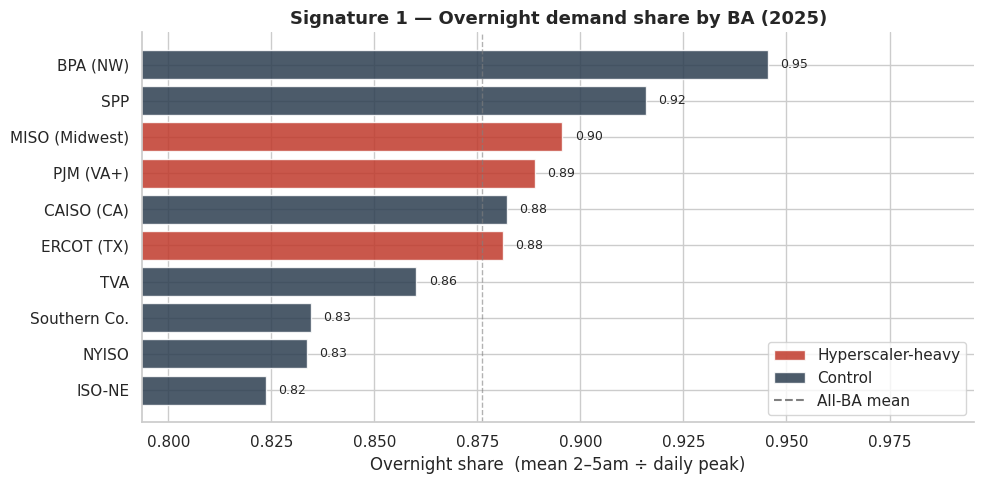


Hyperscaler mean: 0.889
Control mean:     0.871
Gap (pp):         1.78


In [3]:
def overnight_share(series):
    s = series.dropna()
    daily = s.groupby(s.index.date)
    peak  = daily.max()
    night = s[s.index.hour.isin([2, 3, 4, 5])].groupby(lambda t: t.date()).mean()
    aligned = pd.concat([peak, night], axis=1, keys=['peak', 'night']).dropna()
    return (aligned['night'] / aligned['peak']).mean()

overnight = pd.Series({ba: overnight_share(gen[ba]) for ba in BA_ORDER}, name='overnight_share')
overnight_sorted = overnight.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ba_color(ba) for ba in overnight_sorted.index]
bars = ax.barh(range(len(overnight_sorted)), overnight_sorted.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(overnight_sorted)))
ax.set_yticklabels([BA_LABELS[ba] for ba in overnight_sorted.index])
ax.set_xlabel('Overnight share  (mean 2–5am ÷ daily peak)')
ax.set_title('Signature 1 — Overnight demand share by BA (2025)',
             fontsize=13, fontweight='bold')
ax.axvline(overnight.mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label=f'All-BA mean ({overnight.mean():.2f})')
for i, v in enumerate(overnight_sorted.values):
    ax.text(v + 0.003, i, f'{v:.2f}', va='center', fontsize=9)
from matplotlib.patches import Patch
legend = [Patch(facecolor=HYPER_COLOR, alpha=0.85, label='Hyperscaler-heavy'),
          Patch(facecolor=CTRL_COLOR,  alpha=0.85, label='Control')]
ax.legend(handles=legend + [plt.Line2D([0],[0], color='gray', linestyle='--', label=f'All-BA mean')],
          loc='lower right', frameon=True)
ax.set_xlim(overnight.min() - 0.03, overnight.max() + 0.05)
sns.despine()
plt.tight_layout()
plt.show()

print('\nHyperscaler mean:', round(overnight[HYPERSCALER].mean(), 3))
print('Control mean:    ', round(overnight[CONTROL].mean(), 3))
print('Gap (pp):        ', round((overnight[HYPERSCALER].mean() - overnight[CONTROL].mean()) * 100, 2))

## Signature 2 — Weekend ratio

`mean(weekend demand) / mean(weekday demand)`. This is the cleanest single-year signal because **fuel mix does not depend on day-of-week** — nuclear, hydro, and solar produce the same on Saturdays. Any weekend dip is pure demand-side composition.

Traditional industrial+commercial grids sit around **0.93–0.96**. A grid with growing 24/7 server load should sit higher — closer to 1.00 — because servers don't take weekends off.

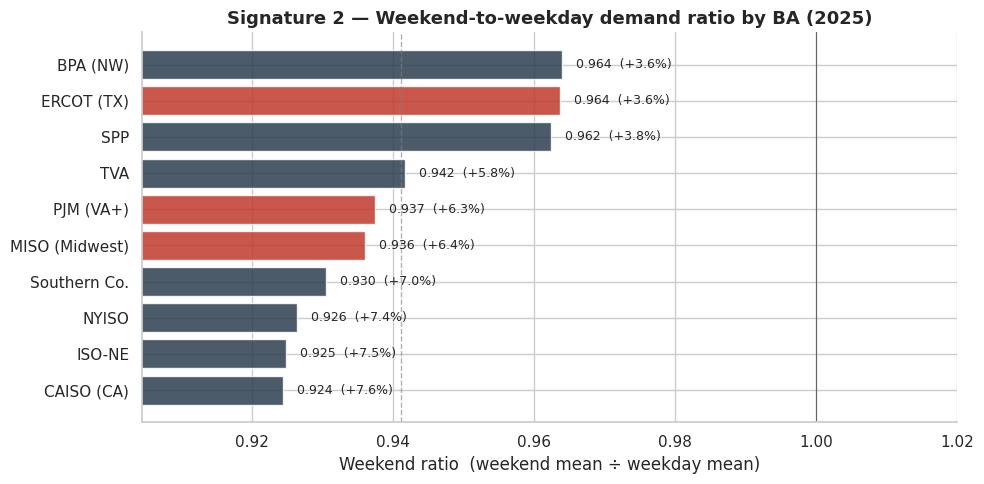


Hyperscaler mean ratio: 0.9457
Control mean ratio:     0.9392
Hyperscaler weekend dip: 5.43 %
Control weekend dip:     6.08 %


In [4]:
def weekend_ratio(series):
    s = series.dropna()
    is_weekend = s.index.dayofweek.isin([5, 6])
    return s[is_weekend].mean() / s[~is_weekend].mean()

weekend = pd.Series({ba: weekend_ratio(gen[ba]) for ba in BA_ORDER}, name='weekend_ratio')
weekend_sorted = weekend.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ba_color(ba) for ba in weekend_sorted.index]
ax.barh(range(len(weekend_sorted)), weekend_sorted.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(weekend_sorted)))
ax.set_yticklabels([BA_LABELS[ba] for ba in weekend_sorted.index])
ax.set_xlabel('Weekend ratio  (weekend mean ÷ weekday mean)')
ax.set_title('Signature 2 — Weekend-to-weekday demand ratio by BA (2025)',
             fontsize=13, fontweight='bold')
ax.axvline(1.00, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axvline(weekend.mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6)
for i, v in enumerate(weekend_sorted.values):
    dip_pct = (1 - v) * 100
    label = f'{v:.3f}  ({dip_pct:+.1f}%)'
    ax.text(v + 0.002, i, label, va='center', fontsize=9)
ax.set_xlim(weekend.min() - 0.02, 1.02)
sns.despine()
plt.tight_layout()
plt.show()

print('\nHyperscaler mean ratio:', round(weekend[HYPERSCALER].mean(), 4))
print('Control mean ratio:    ', round(weekend[CONTROL].mean(), 4))
print('Hyperscaler weekend dip:', round((1 - weekend[HYPERSCALER].mean()) * 100, 2), '%')
print('Control weekend dip:    ', round((1 - weekend[CONTROL].mean()) * 100, 2), '%')

## Signature 3 — Load duration curve

Sort each BA's 8,760 hourly values descending, normalize to that BA's peak. X-axis is percentile of hours (0 = peak hour, 100 = lowest hour). A residential-heavy grid drops steeply toward the bottom. A grid with 24/7 baseload (data centers) has a fatter bottom tail.

We overlay all 10 BAs, colored by group.

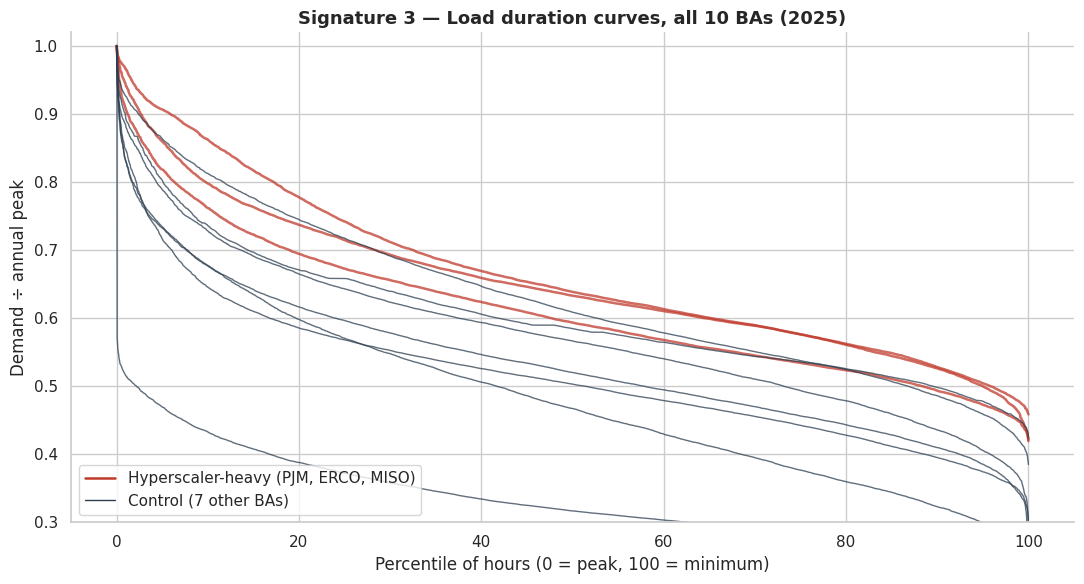


Bottom-decile floor (demand at the 90th-percentile hour, fraction of peak):
SOCO    0.255
CISO    0.323
NYIS    0.395
ISNE    0.410
BPAT    0.436
TVA     0.486
PJM     0.493
SWPP    0.498
MISO    0.526
ERCO    0.528

Hyperscaler mean floor: 0.516
Control mean floor:     0.400


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

ldc_bottom_decile = {}
for ba in BA_ORDER:
    s = gen[ba].dropna().values
    sorted_desc = np.sort(s)[::-1] / s.max()
    pct = np.linspace(0, 100, len(sorted_desc))
    ax.plot(pct, sorted_desc, color=ba_color(ba), alpha=0.75,
            linewidth=1.8 if ba in HYPERSCALER else 1.0,
            label=BA_LABELS[ba] if ba in HYPERSCALER else None)
    # value at 90th-percentile hour (i.e. the bottom 10% of hours)
    ldc_bottom_decile[ba] = sorted_desc[int(len(sorted_desc) * 0.9)]

ax.set_xlabel('Percentile of hours (0 = peak, 100 = minimum)')
ax.set_ylabel('Demand ÷ annual peak')
ax.set_title('Signature 3 — Load duration curves, all 10 BAs (2025)',
             fontsize=13, fontweight='bold')

# explicit handles for the two-group legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], color=HYPER_COLOR, lw=1.8, label='Hyperscaler-heavy (PJM, ERCO, MISO)'),
          Line2D([0],[0], color=CTRL_COLOR,  lw=1.0, label='Control (7 other BAs)')]
ax.legend(handles=legend, loc='lower left', frameon=True)
ax.set_ylim(0.3, 1.02)
sns.despine()
plt.tight_layout()
plt.show()

bottom = pd.Series(ldc_bottom_decile, name='bottom_decile_floor').sort_values()
print('\nBottom-decile floor (demand at the 90th-percentile hour, fraction of peak):')
print(bottom.round(3).to_string())
print(f'\nHyperscaler mean floor: {bottom[HYPERSCALER].mean():.3f}')
print(f'Control mean floor:     {bottom[CONTROL].mean():.3f}')

## Go / no-go summary

Cross-sectional verdict for 2025, all three signatures side by side. The thesis predicts the three hyperscaler BAs cluster above the control on all three metrics. One-of-three is weak; two-of-three is suggestive; three-of-three justifies pulling 2019–2024 per-BA history to build the full trend story.

In [6]:
summary = pd.DataFrame({
    'overnight_share': overnight,
    'weekend_ratio':   weekend,
    'ldc_floor_p90':   pd.Series(ldc_bottom_decile),
}).loc[BA_ORDER]
summary['group'] = ['hyper' if ba in HYPERSCALER else 'ctrl' for ba in summary.index]

print('Per-BA:')
print(summary.round(3).to_string())

group_means = summary.groupby('group').mean(numeric_only=True).round(4)
gap = (group_means.loc['hyper'] - group_means.loc['ctrl']).round(4)
print('\nGroup means:')
print(group_means.to_string())
print('\nHyper − Ctrl gap:')
print(gap.to_string())

signals = {
    'overnight_share': gap['overnight_share'] > 0.01,  # > 1 pp
    'weekend_ratio':   gap['weekend_ratio']   > 0.005, # > 0.5 pp
    'ldc_floor_p90':   gap['ldc_floor_p90']   > 0.01,  # > 1 pp of peak
}
hits = sum(signals.values())
print(f'\nSignatures with hyperscaler > control: {hits}/3')
for k, v in signals.items():
    print(f'  {k}: {"✓" if v else "✗"}')

verdict = {3: 'STRONG — pull the 2019–2024 backfill, build Stage A',
           2: 'SUGGESTIVE — probably pull backfill, caveat clearly',
           1: 'WEAK — one metric alone; consider alternative anchors',
           0: 'NO SIGNAL — reject data-center anchor, pivot framing'}
print(f'\nVerdict: {verdict[hits]}')

Per-BA:
      overnight_share  weekend_ratio  ldc_floor_p90  group
PJM             0.889          0.937          0.493  hyper
ERCO            0.881          0.964          0.528  hyper
MISO            0.896          0.936          0.526  hyper
BPAT            0.945          0.964          0.436   ctrl
CISO            0.882          0.924          0.323   ctrl
ISNE            0.824          0.925          0.410   ctrl
NYIS            0.834          0.926          0.395   ctrl
SOCO            0.835          0.930          0.255   ctrl
SWPP            0.916          0.962          0.498   ctrl
TVA             0.860          0.942          0.486   ctrl

Group means:
       overnight_share  weekend_ratio  ldc_floor_p90
group                                               
ctrl            0.8708         0.9392         0.4003
hyper           0.8886         0.9457         0.5159

Hyper − Ctrl gap:
overnight_share    0.0178
weekend_ratio      0.0065
ldc_floor_p90      0.1156

Signatures with hyp